# **IMPORT LIBRARIES**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*reading the data, and analyzing the data*

In [13]:
df = pd.read_csv('data.csv')

In [14]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [15]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [16]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [18]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


## **Cleaning Data**

Remove duplicates - we only want unique car models

In [21]:
df = df.drop_duplicates()

Handle Missing Values
For Horsepower and Cylinders, we use the median (middle value)
so that super-cars don't skew our averages.

In [22]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

For Doors, we just use the most common number (the mode)

In [23]:
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].mode()[0])

## **FEATURE ENGINEERING**

Calculate the age of the car (relative to 2018)

In [24]:
df['Car_Age'] = 2018 - df['Year']

HP per Cylinder (a quick metric for engine power density)

In [25]:
df['HP_per_Cylinder'] = df['Engine HP'] / (df['Engine Cylinders'].replace(0, 1))

## **BASIC VISUALIZATION**

In [27]:
sns.set_theme(style="whitegrid")

1. Top 10 Car Brands

/tmp/ipykernel_984/2855499220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette='viridis')


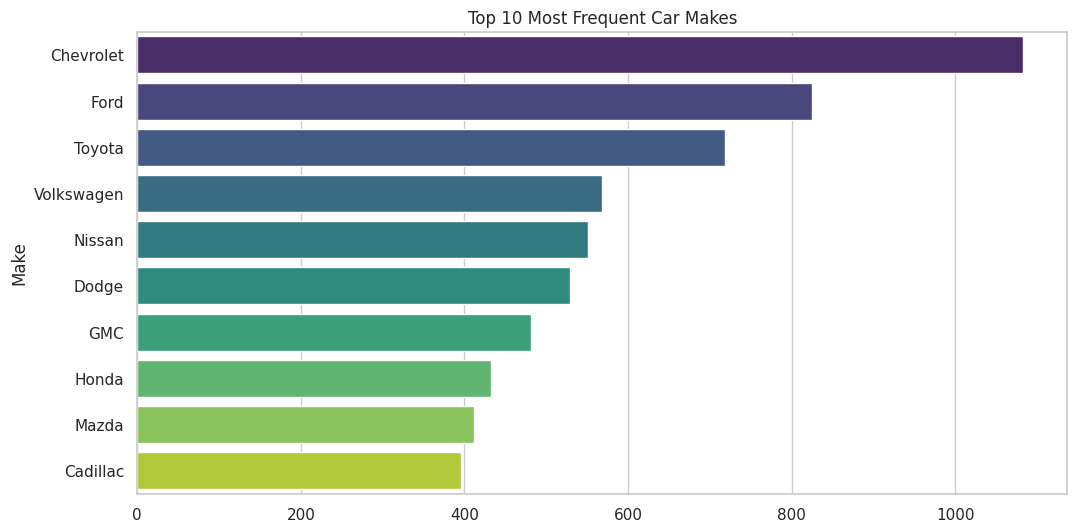

In [32]:
plt.figure(figsize=(12, 6))
top_makes = df['Make'].value_counts().head(10)
sns.barplot(x=top_makes.values, y=top_makes.index, palette='viridis')
plt.title('Top 10 Most Frequent Car Makes')
plt.show()

2. Price Distribution

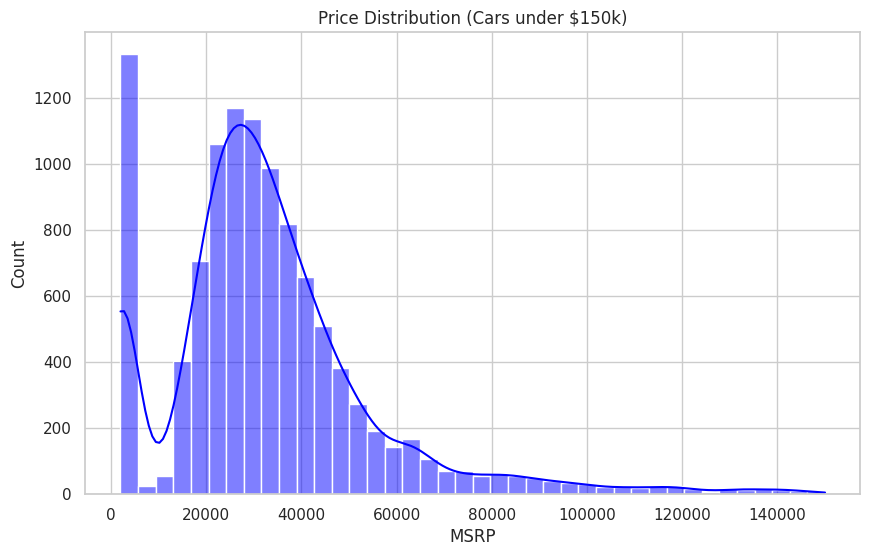

In [31]:
plt.figure(figsize=(10, 6))
# We clip at $150k so the $2 Million cars don't make the chart unreadable
sns.histplot(df[df['MSRP'] < 150000]['MSRP'], bins=40, kde=True, color='blue')
plt.title('Price Distribution (Cars under $150k)')
plt.show()

# **ADVANCED VISUALIZATION**

3. Correlation Heatmap

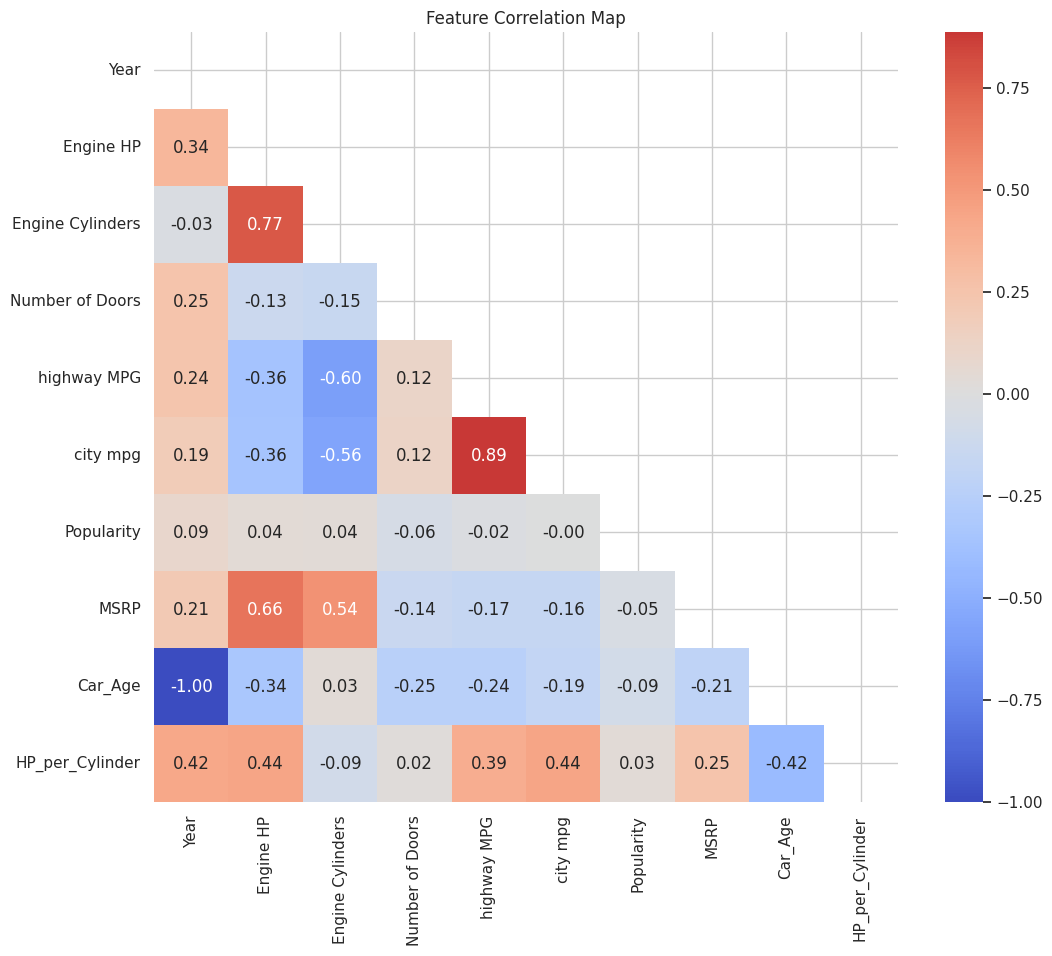

In [34]:
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Hides the mirrored top half
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Feature Correlation Map')
plt.show()

4. Power vs Price

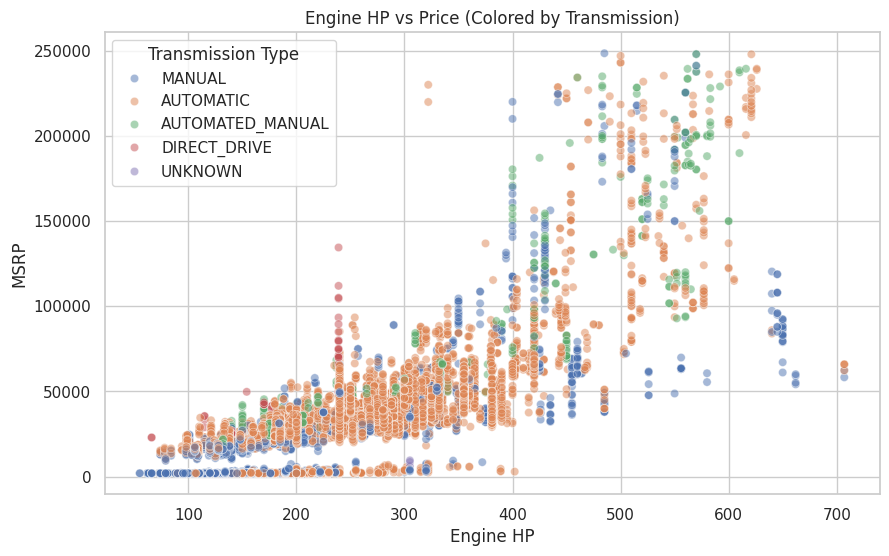

In [36]:
plt.figure(figsize=(10, 6))
# Scatter plot with 'hue' shows how Transmission Type shifts the price/power curve
sns.scatterplot(data=df[df['MSRP'] < 250000], x='Engine HP', y='MSRP', hue='Transmission Type', alpha=0.5)
plt.title('Engine HP vs Price (Colored by Transmission)')
plt.show()

## **Expert Analytics**

5. Price Variance by Style (Log Scale)

/tmp/ipykernel_984/267835149.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Vehicle Style', y='MSRP', palette='Set3')


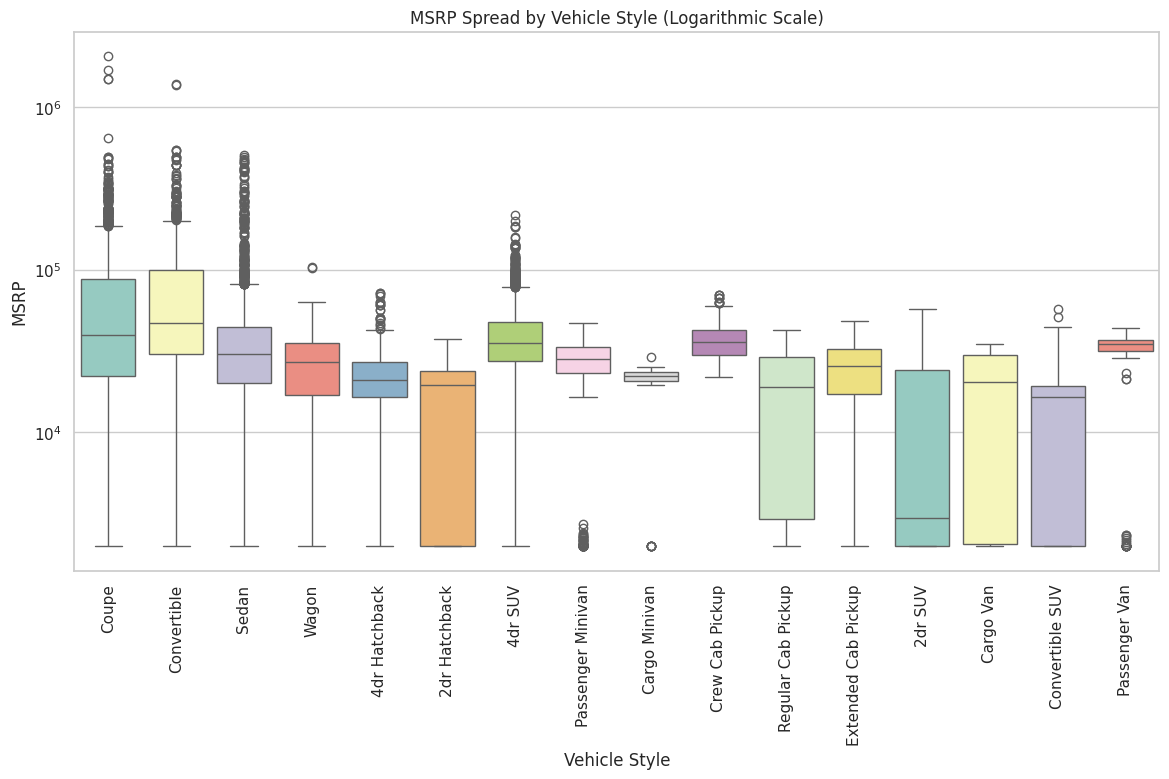

In [38]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Vehicle Style', y='MSRP', palette='Set3')
plt.yscale('log') # Use Log scale to handle both $2,000 and $2,000,000 cars
plt.xticks(rotation=90)
plt.title('MSRP Spread by Vehicle Style (Logarithmic Scale)')
plt.show()

6. Faceted Comparison: Efficiency vs Age

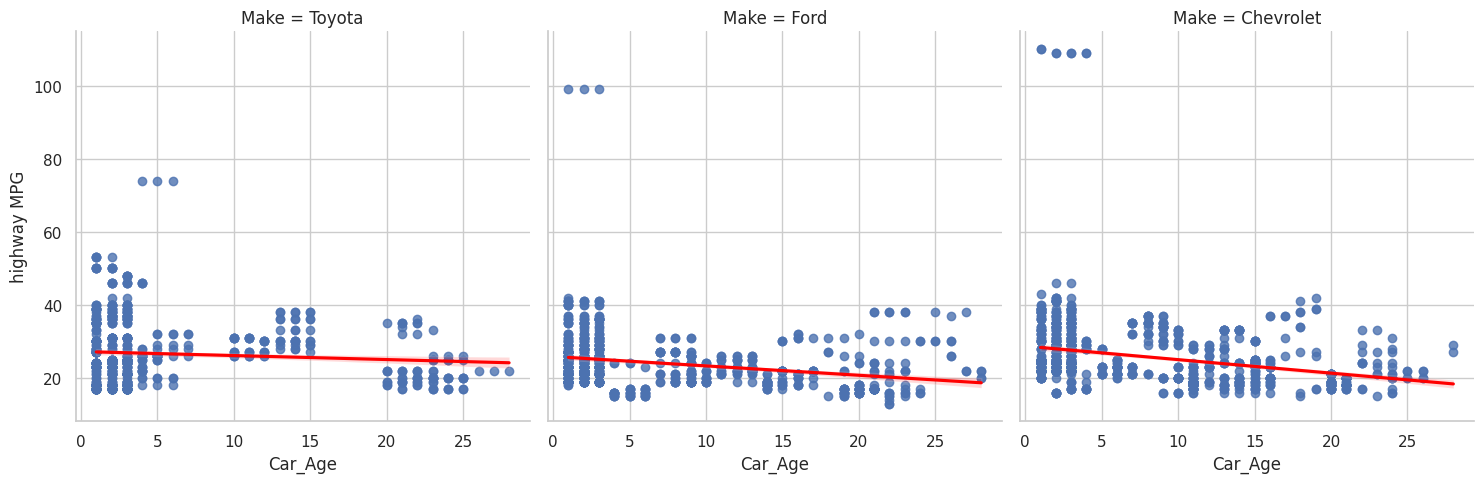

In [40]:
top_3_brands = df['Make'].value_counts().head(3).index
g = sns.FacetGrid(df[df['Make'].isin(top_3_brands)], col="Make", height=5)
g.map(sns.regplot, "Car_Age", "highway MPG", line_kws={'color':'red'})
plt.show()

7. Joint Hex Plot: City vs Highway MPG density

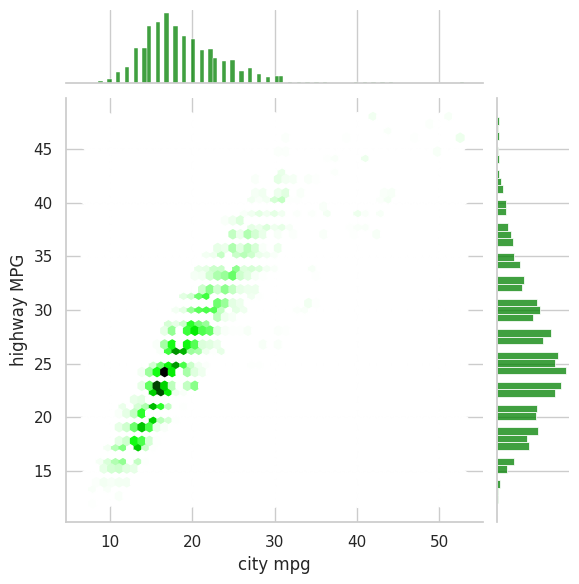

In [42]:
sns.jointplot(data=df[df['highway MPG'] < 50], x='city mpg', y='highway MPG', kind='hex', color='green')
plt.show()